In [1]:
%load_ext autoreload
%autoreload 2

import os
os.chdir('/workspace-SR006.nfs2/bulatov/rmt/test-time/test_time_gd')

In [2]:
# set pandas max rows to 250
import pandas as pd
pd.set_option('display.max_rows', 250)

In [3]:
from pathlib import Path
import json

runs_path = Path('/workspace-SR006.nfs2/bulatov/rmt/runs/test-time')

runs = []
for run_path in runs_path.glob('**/*/*/run_*'):
    if run_path.is_dir():
        run_stats = {}
        run_stats['run_name'] = run_path.parent.name
        run_stats['task_name'] = run_path.parent.parent.name
        run_stats['run_path'] = run_path
        run_stats['run_id'] = int(run_path.name.split('_')[1])
        # add cli args
        run_stats.update(json.load(open(run_path / 'config.json'))['cli_args'])
        # add results
        results_path = run_path / 'all_results.json'
        if results_path.exists():
            results = json.load(open(results_path, 'r'))
            run_stats.update(results)
        runs += [run_stats]

import pandas as pd
df = pd.DataFrame(runs)
df['gradmem'] = df['run_name'].apply(lambda x: 'gradmem' in x)
df['rmt'] = df['run_name'].apply(lambda x: 'rmt' in x)
df.eval_exact_match = df.eval_exact_match.fillna(df.eval_exact_match_base)
df['eval_exact_match_mem_task'] = None
df['eval_exact_match_mem_task'] = df.eval_exact_match_mem_task.fillna(df.eval_exact_match_reconstruct)
df['eval_exact_match_mem_task'] = df.eval_exact_match_mem_task.fillna(df.eval_exact_match_continue)
# df['base_model'] = df['base_model'].fillna('gpt2')
# df

/tmp/ipykernel_2681226/2798494451.py:29: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['eval_exact_match_mem_task'] = df.eval_exact_match_mem_task.fillna(df.eval_exact_match_reconstruct)


In [4]:
# df[df['run_name'].apply(lambda x: 'armt' in x)]

In [5]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)


# group by run_name, task_name
# show mean and std of token_accuracy and exact_match
g = df.groupby(['task_name', 'run_name']).agg({
    # 'gradmem': 'first',
    'rmt': 'first',
    'eval_token_accuracy': ['mean', 'std', list], 
    'eval_exact_match': ['mean', 'std', list],
    'eval_exact_match_mem_task': ['mean', 'std', list],
    'run_path': 'first',
    # 'base_model': 'first',
    # 'K': 'first',
    # 'inner_lr': 'first',
    # 'n_mem_tokens': 'first',
    # 'use_adam': 'first',
    # 'grad_mode': 'first',
    # 'inner_clip_norm': 'first',
    # 'learning_rate': 'first',
    # 'n_ctrl_tokens': 'first',
    # 'mem_proj_mode': 'first',
    # 'use_write_head': 'first',
    # 'max_position_embeddings': 'first',
    # 'adam_beta2': 'first',
})
g = g.reset_index()
# g = g.sort_values(by=['task_name', ('eval_token_accuracy', 'mean')], ascending=False)
g = g.sort_values(by=['task_name', ('eval_exact_match', 'mean')], ascending=False)
# # sort run_name by eval_token_accuracy mean inside of each group, keep grouping by task_name
# g = g.groupby(level=0).apply(lambda x: x.sort_values(('eval_token_accuracy', 'mean'), ascending=False))
# g

# K ~ 1, large LR
# mem < 8
# 
# 


# !Ø:▮!!e:Ⓜ!!d:😥!!😝:🙏!|      ?!Ø:   ▮!|
# context, 1st segment          query, 2nd segment


# g[g['task_name'] == 'N4-K1V1-V512_1M']
# g[g['task_name'] == 'N4-K1V1-V62_1M']
# g[g['task_name'] == 'N4-K2V2-V62_1M']
# g[g['task_name'] == 'N4-K2V2-V512_1M']
# g[g['task_name'] == 'N8-K1V1-V512_1M']
# g[g['task_name'] == 'N8-K1V1-V62_1M']
# g[g['task_name'] == 'N8-K2V2-V512_1M']
# g[g['task_name'] == 'N8-K2V2-V62_1M']
# g[g['task_name'] == 'N8-K2V2-V62_noise_0.25_1M']
# g[g['task_name'] == 'N8-K2V2-V62_noise_0.5_1M']
# g[g['task_name'] == 'N8-K2V2-V62_noise_0.75_1M']
# g[g['task_name'] == 'N16-K1V1-V512_1M']
# g[g['task_name'] == 'N16-K1V1-V62_1M']
# g[g['task_name'] == 'N16-K2V2-V512_1M']
# g[g['task_name'] == 'N16-K2V2-V62_1M']
# g[g['task_name'] == 'N32-K1V1-V512_1M']
# g[g['task_name'] == 'N32-K1V1-V62_1M']
# g[g['task_name'] == 'N32-K2V2-V512_1M']
# g[g['task_name'] == 'N32-K2V2-V62_1M']
# g[g['task_name'] == 'N64-K2V2-V62_1M']

# g[g['task_name'].str.contains('babilong')].sort_values(by='task_name', ascending=True)
# g[g['task_name'].str.contains('squad')].sort_values(by='task_name', ascending=True)
# g.sort_values(by='task_name', ascending=False)


# g[g['task_name'] == 'N2-K4V4-S4(32-64)_1M']
# g[g['task_name'] == 'N10-K2V2-S4(32-64)_1M']
# g[g['task_name'] == 'N2-K4V4-S1(16-32)_1M']

In [6]:
def get_mod(run_name):
    if 'continue' in run_name:
        return 'continue'
    elif 'reconstruct' in run_name:
        return 'reconstruct'
    else:
        return '-'


In [7]:
import re

def extract_lr_and_mem(run_name):
    # Try to extract mem size (e.g. mem8 or mem_8)
    # mem_match = re.search(r'mem[_]?(\d+)', run_name)
    # mem_size = mem_match.group(1) if mem_match else None
    mem_size = run_name.split('mem')[1].split('_')[0]

    # Try to extract learning rate (e.g. lr1e-04 or lr_1e-04)
    # Prefer the last occurrence of lr (to avoid model lr vs. optimizer lr confusion)
    lr_matches = list(re.finditer(r'lr[_]?([0-9.eE+-]+)', run_name))
    lr = lr_matches[-1].group(1) if lr_matches else None

    return lr, mem_size

# Apply extraction to armt_runs
armt_runs = g[g['run_name'].str.contains('armt')].copy()
armt_runs['lr'], armt_runs['mem_size'] = zip(*armt_runs['run_name'].map(extract_lr_and_mem))

armt_runs['modification'] = armt_runs.run_name.apply(get_mod)

new_df = armt_runs[['task_name', 'run_name', 'lr', 'mem_size', 'modification']].copy()

# new_df = armt_runs[['task_name', 'run_name', 'lr', 'mem_size']].copy()
new_df['eval_exact_match'] = armt_runs['eval_exact_match']['mean']

# grouped = new_df.groupby(['task_name', 'mem_size']).apply(lambda x: x.sort_values(by='eval_exact_match', ascending=False).head(1))
grouped = new_df.groupby(['task_name', 'mem_size', 'modification']).apply(lambda x: x.sort_values(by='eval_exact_match', ascending=False).head(1)).dropna()
grouped.loc['N8-K2V2-V62_1M'][['eval_exact_match']]



/tmp/ipykernel_2681226/3942625042.py:28: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  grouped = new_df.groupby(['task_name', 'mem_size', 'modification']).apply(lambda x: x.sort_values(by='eval_exact_match', ascending=False).head(1)).dropna()
/tmp/ipykernel_2681226/3942625042.py:28: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped = new_df.groupby(['task_name', 'mem_size', 'modification']).apply(lambda x: x.sort_values(by='eval_exact_match', ascending=False).head(1)).dropna()


eval_exact_match
                                          
mem_size modification                     
8        -            154         0.856100
8-1024   -            139         0.405000
8-16     -            140         0.715200
8-32     -            160         0.757100
         continue     141         0.995620
         reconstruct  142         0.979961
8-512    -            150         0.549300
8-8      -            152         0.593600

In [8]:
import re

def extract_lr_and_mem(run_name):
    # Try to extract mem size (e.g. mem8 or mem_8)
    # mem_match = re.search(r'mem[_]?(\d+)', run_name)
    # mem_size = mem_match.group(1) if mem_match else None
    mem_size = run_name.split('mem')[1].split('_')[0]

    # Try to extract learning rate (e.g. lr1e-04 or lr_1e-04)
    # Prefer the last occurrence of lr (to avoid model lr vs. optimizer lr confusion)
    lr_matches = list(re.finditer(r'lr[_]?([0-9.eE+-]+)', run_name))
    lr = lr_matches[-1].group(1) if lr_matches else None

    return lr, mem_size

# Apply extraction to armt_runs
armt_runs = g[g['run_name'].str.contains('armt')].copy()
armt_runs['lr'], armt_runs['mem_size'] = zip(*armt_runs['run_name'].map(extract_lr_and_mem))

armt_runs['modification'] = armt_runs.run_name.apply(get_mod)

new_df = armt_runs[['task_name', 'run_name', 'lr', 'mem_size', 'modification']].copy()

# new_df = armt_runs[['task_name', 'run_name', 'lr', 'mem_size']].copy()
new_df['eval_exact_match'] = armt_runs['eval_exact_match']['mean']

# grouped = new_df.groupby(['task_name', 'mem_size']).apply(lambda x: x.sort_values(by='eval_exact_match', ascending=False).head(1))
grouped = new_df.groupby(['task_name', 'mem_size', 'modification']).apply(lambda x: x.sort_values(by='eval_exact_match', ascending=False).head(1)).dropna()
grouped.loc['N8-K2V2-V62_1M'][['eval_exact_match']]



/tmp/ipykernel_2681226/3942625042.py:28: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  grouped = new_df.groupby(['task_name', 'mem_size', 'modification']).apply(lambda x: x.sort_values(by='eval_exact_match', ascending=False).head(1)).dropna()
/tmp/ipykernel_2681226/3942625042.py:28: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped = new_df.groupby(['task_name', 'mem_size', 'modification']).apply(lambda x: x.sort_values(by='eval_exact_match', ascending=False).head(1)).dropna()


eval_exact_match
                                          
mem_size modification                     
8        -            154         0.856100
8-1024   -            139         0.405000
8-16     -            140         0.715200
8-32     -            160         0.757100
         continue     141         0.995620
         reconstruct  142         0.979961
8-512    -            150         0.549300
8-8      -            152         0.593600

In [9]:
rmt_runs = g[~g['run_name'].str.contains('armt')].copy()
rmt_runs['lr'], rmt_runs['mem_size'] = zip(*rmt_runs['run_name'].map(extract_lr_and_mem))
rmt_runs['modification'] = rmt_runs.run_name.apply(get_mod)

new_df = rmt_runs[['task_name', 'run_name',
                   'run_path', 
                   'lr', 'mem_size', 'modification']].copy()
new_df['eval_exact_match'] = rmt_runs['eval_exact_match']['mean']

grouped = new_df.groupby(['task_name', 'mem_size', 'modification']).apply(lambda x: x.sort_values(by='eval_exact_match', ascending=False).head(1))
# grouped.loc['N8-K2V2-V62_1M'][['eval_exact_match']]
# grouped



/tmp/ipykernel_2681226/3133405952.py:10: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  grouped = new_df.groupby(['task_name', 'mem_size', 'modification']).apply(lambda x: x.sort_values(by='eval_exact_match', ascending=False).head(1))
/tmp/ipykernel_2681226/3133405952.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped = new_df.groupby(['task_name', 'mem_size', 'modification']).apply(lambda x: x.sort_values(by='eval_exact_match', ascending=False).head(1))


In [10]:
# armt_runs[armt_runs.modification == '-'][['task_name', 'run_name', 'lr', 'mem_size', 'eval_exact_match']]

In [11]:
# rmt_runs[(rmt_runs.task_name == 'N16-K2V2-V62_1M') \
#         # (rmt_runs.lr == '3e-04')# &\
#         # (rmt_runs.modification == '-')# &\
#         # (rmt_runs.run_name.str.contains('original_rmt-vl'))
#         ].sort_values(by=('eval_exact_match', 'mean'), ascending=False).head(20)

- no_tf == '.' as input, i.e. parallel decoding
- no_context == attn only at current token and memory
- no_pos_emb == all positions = 0
- TBD: for base AR add GT positional encodings to target

In [16]:
rmt_runs[(rmt_runs.task_name == 'N8-K2V2-V62_1M') \
        # (rmt_runs.lr == '3e-04')# &\
        & (rmt_runs.modification == '-')# &\
        # & (rmt_runs.run_name.str.contains('reconstruct_1'))
        # & (rmt_runs.run_name.str.contains('mem1_'))
        # & (rmt_runs.run_name.str.contains('bs_256'))
        ].sort_values(by=('eval_token_accuracy', 'mean'), ascending=False).head(20)

task_name  \
                      
227  N8-K2V2-V62_1M   
258  N8-K2V2-V62_1M   
250  N8-K2V2-V62_1M   
248  N8-K2V2-V62_1M   
249  N8-K2V2-V62_1M   
174  N8-K2V2-V62_1M   
263  N8-K2V2-V62_1M   
183  N8-K2V2-V62_1M   
234  N8-K2V2-V62_1M   
165  N8-K2V2-V62_1M   
266  N8-K2V2-V62_1M   
201  N8-K2V2-V62_1M   
228  N8-K2V2-V62_1M   
226  N8-K2V2-V62_1M   
203  N8-K2V2-V62_1M   
232  N8-K2V2-V62_1M   
267  N8-K2V2-V62_1M   
262  N8-K2V2-V62_1M   
196  N8-K2V2-V62_1M   
202  N8-K2V2-V62_1M   

                                                                        run_name  \
                                                                                   
227  original_rmt_llama_L4H4D128_mem1_lr1e-04_help_with_pos_id-v3_bs_64_lr_1e-04   
258              original_rmt_llama_L4H4D128_mem8_lr3e-04_from_N4_bs_64_lr_3e-04   
250              original_rmt_llama_L4H4D128_mem8_lr1e-04_from_N4_bs_64_lr_1e-04   
248                     original_rmt_llama_L4H4D128_mem8_lr1e-04_bs_256_lr_1e-04   
249                      original_rmt_llama_L4H4D128_mem8_lr1e-04_bs_64_lr_1e-04   
174      original_rmt-vl_llama_L4H4D128-out_layer_-2_mem8_lr1e-04_bs_64_lr_1e-04   
263                      original_rmt_llama_L4H4D256_mem8_lr1e-04_bs_64_lr_1e-04   
183      original_rmt-vl_llama_L4H4D128-out_layer_-3_mem8_lr1e-04_bs_64_lr_1e-04   
234                         original_rmt_llama_L4H4D128_mem8_bs_64_lr_1e-04 copy   
165      original_rmt-vl_llama_L4H4D128-out_layer_-1_mem8_lr1e-04_bs_64_lr_1e-04   
266                      original_rmt_llama_L4H8D128_mem8_lr1e-04_bs_64_lr_1e-04   
201                     original_rmt_llama_L4H2D128_mem8_lr1e-04_bs_256_lr_1e-04   
228     original_rmt_llama_L4H4D128_mem1_lr1e-04_help_with_pos_id_bs_64_lr_1e-04   
226  original_rmt_llama_L4H4D128_mem1_lr1e-04_help_with_pos_id-v2_bs_64_lr_1e-04   
203                     original_rmt_llama_L4H4D128_mem16_lr1e-04_bs_64_lr_1e-04   
232                      original_rmt_llama_L4H4D128_mem2_lr1e-04_bs_64_lr_1e-04   
267                      original_rmt_llama_L8H4D128_mem8_lr1e-04_bs_64_lr_1e-04   
262                      original_rmt_llama_L4H4D128_mem8_lr9e-05_bs_64_lr_9e-05   
196      original_rmt-vl_llama_L4H4D128-out_layer_-4_mem8_lr3e-04_bs_64_lr_3e-04   
202                      original_rmt_llama_L4H2D128_mem8_lr1e-04_bs_64_lr_1e-04   

      rmt eval_token_accuracy                             eval_exact_match  \
    first                mean       std              list             mean   
227  True             0.99870       NaN          [0.9987]           0.9974   
258  True             0.99310  0.000424  [0.9934, 0.9928]           0.9862   
250  True             0.99180  0.000424  [0.9921, 0.9915]           0.9837   
248  True             0.96655  0.022698  [0.9826, 0.9505]           0.9347   
249  True             0.88385  0.058478  [0.8425, 0.9252]           0.7875   
174  True             0.86750  0.058831  [0.8259, 0.9091]           0.7660   
263  True             0.85090  0.040729  [0.8221, 0.8797]           0.7379   
183  True             0.82535  0.036416  [0.7996, 0.8511]           0.7002   
234  True             0.80435  0.034578  [0.7799, 0.8288]           0.6614   
165  True             0.79985  0.049568  [0.8349, 0.7648]           0.6547   
266  True             0.61925  0.228183  [0.4579, 0.7806]           0.4528   
201  True             0.60515  0.538038  [0.9856, 0.2247]           0.5076   
228  True             0.58400       NaN           [0.584]           0.1684   
226  True             0.58220       NaN          [0.5822]           0.1648   
203  True             0.57060  0.566958  [0.9715, 0.1697]           0.4872   
232  True             0.56400  0.042709  [0.5942, 0.5338]           0.3423   
267  True             0.54150  0.006647  [0.5368, 0.5462]           0.1271   
262  True             0.53915  0.521208  [0.1706, 0.9077]           0.4283   
196  True             0.52830  0.041436   [0.499, 0.5576]           0.1770   
202  True       

In [ ]:
rmt_runs[(rmt_runs.task_name == 'N8-K2V2-V62_1M') \
        # (rmt_runs.lr == '3e-04')# &\
        # (rmt_runs.modification == '-')# &\
        # & (rmt_runs.run_name.str.contains('reconstruct_1'))
        & (rmt_runs.run_name.str.contains('mem1_'))
        # & (rmt_runs.run_name.str.contains('bs_256'))
        ].sort_values(by=('eval_token_accuracy', 'mean'), ascending=False).head(20)

task_name  \
                      
222  N8-K2V2-V62_1M   
218  N8-K2V2-V62_1M   
217  N8-K2V2-V62_1M   
227  N8-K2V2-V62_1M   
204  N8-K2V2-V62_1M   
208  N8-K2V2-V62_1M   
223  N8-K2V2-V62_1M   
220  N8-K2V2-V62_1M   
221  N8-K2V2-V62_1M   
214  N8-K2V2-V62_1M   
230  N8-K2V2-V62_1M   
206  N8-K2V2-V62_1M   
228  N8-K2V2-V62_1M   
226  N8-K2V2-V62_1M   
210  N8-K2V2-V62_1M   
212  N8-K2V2-V62_1M   
207  N8-K2V2-V62_1M   
211  N8-K2V2-V62_1M   
224  N8-K2V2-V62_1M   
229  N8-K2V2-V62_1M   

                                                                                     run_name  \
                                                                                                
222               original_rmt_llama_L4H4D128_mem1_lr1e-04-reconstruct_1_no_tf_bs_64_lr_1e-04   
218    original_rmt_llama_L4H4D128_mem1_lr1e-04-reconstruct_1_no_context_no_tf_bs_64_lr_1e-04   
217          original_rmt_llama_L4H4D128_mem1_lr1e-04-reconstruct_1_no_context_bs_64_lr_1e-04   
227               original_rmt_llama_L4H4D128_mem1_lr1e-04_help_with_pos_id-v3_bs_64_lr_1e-04   
204                   original_rmt_llama_L4H4D128_mem1_lr1e-04-continue_1_4-16_bs_64_lr_1e-04   
208                   original_rmt_llama_L4H4D128_mem1_lr1e-04-continue_1_4-32_bs_64_lr_1e-04   
223    original_rmt_llama_L4H4D128_mem1_lr1e-04-reconstruct_1_no_tf_no_pos_emb_bs_64_lr_1e-04   
220  original_rmt_llama_L4H4D128_mem1_lr1e-04-reconstruct_1_no_context_pos_emb_bs_64_lr_1e-04   
221          original_rmt_llama_L4H4D128_mem1_lr1e-04-reconstruct_1_no_pos_emb_bs_64_lr_1e-04   
214                   original_rmt_llama_L4H4D128_mem1_lr1e-04-reconstruct_0.5_bs_64_lr_1e-04   
230                   original_rmt_llama_L4H4D128_mem1_lr3e-04-reconstruct_0.5_bs_64_lr_3e-04   
206                    original_rmt_llama_L4H4D128_mem1_lr1e-04-continue_1_4-2_bs_64_lr_1e-04   
228                  original_rmt_llama_L4H4D128_mem1_lr1e-04_help_with_pos_id_bs_64_lr_1e-04   
226               original_rmt_llama_L4H4D128_mem1_lr1e-04_help_with_pos_id-v2_bs_64_lr_1e-04   
210                    original_rmt_llama_L4H4D128_mem1_lr1e-04-continue_1_4-4_bs_64_lr_1e-04   
212                    original_rmt_llama_L4H4D128_mem1_lr1e-04-continue_1_4-8_bs_64_lr_1e-04   
207              original_rmt_llama_L4H4D128_mem1_lr1e-04-continue_1_4-2_no_tf_bs_64_lr_1e-04   
211              original_rmt_llama_L4H4D128_mem1_lr1e-04-continue_1_4-4_no_tf_bs_64_lr_1e-04   
224                                  original_rmt_llama_L4H4D128_mem1_lr1e-04_bs_512_lr_1e-04   
229                original_rmt_llama_L4H4D128_mem1_lr1e-04_shift_seg2_pos_ids_bs_64_lr_1e-04   

      rmt eval_token_accuracy            \
    first                mean       std   
222  True            0.999975       NaN   
218  True            0.999860       NaN   
217  True            0.999175       NaN   
227  True            0.998700       NaN   
204  True            0.965874       NaN   
208  True            0.948663       NaN   
223  True            0.915445       NaN   
220  True            0.897555       NaN   
221  True            0.894450       NaN   
214  True            0.860430  0.016763   
230  True            0.849342  0.012101   
206  True            0.584936       NaN   
228  True            0.584000       NaN   
226  True            0.582200       NaN   
210  True            0.503921       NaN   
212  True            0.453240       NaN   
207  True            0.417990       NaN   
211  True            0.263172       NaN   
224  True            0.167200       NaN   
229  True            0.166600       NaN   

                                              eval_exact_match            \
                                         list             mean       std   
222                                [0.999975]              NaN       NaN   
218                                 [0.99986]              NaN       NaN   
217                                [0.999175]              NaN       NaN   
227                                  [0.9

In [ ]:
rmt_runs[(rmt_runs.task_name == 'N8-K2V2-V62_1M') \
        # (rmt_runs.lr == '3e-04')# &\
        # (rmt_runs.modification == '-')# &\
        # & (rmt_runs.run_name.str.contains('reconstruct_1'))
        & (rmt_runs.run_name.str.contains('mem8_'))
        ].sort_values(by=('eval_token_accuracy', 'mean'), ascending=False).head(20)

task_name  \
                      
246  N8-K2V2-V62_1M   
255  N8-K2V2-V62_1M   
254  N8-K2V2-V62_1M   
245  N8-K2V2-V62_1M   
241  N8-K2V2-V62_1M   
247  N8-K2V2-V62_1M   
238  N8-K2V2-V62_1M   
258  N8-K2V2-V62_1M   
250  N8-K2V2-V62_1M   
260  N8-K2V2-V62_1M   
259  N8-K2V2-V62_1M   
235  N8-K2V2-V62_1M   
240  N8-K2V2-V62_1M   
253  N8-K2V2-V62_1M   
248  N8-K2V2-V62_1M   
243  N8-K2V2-V62_1M   
237  N8-K2V2-V62_1M   
181  N8-K2V2-V62_1M   
249  N8-K2V2-V62_1M   
174  N8-K2V2-V62_1M   

                                                                                    run_name  \
                                                                                               
246                    original_rmt_llama_L4H4D128_mem8_lr1e-04-reconstruct_1_bs_64_lr_1e-04   
255                    original_rmt_llama_L4H4D128_mem8_lr3e-04-reconstruct_1_bs_64_lr_3e-04   
254                  original_rmt_llama_L4H4D128_mem8_lr3e-04-reconstruct_0.5_bs_64_lr_3e-04   
245                  original_rmt_llama_L4H4D128_mem8_lr1e-04-reconstruct_0.5_bs_64_lr_1e-04   
241                original_rmt_llama_L4H4D128_mem8_lr1e-04-continue_8-16_0.5_bs_64_lr_1e-04   
247                      original_rmt_llama_L4H4D128_mem8_lr1e-04-reconstruct_bs_64_lr_1e-04   
238                original_rmt_llama_L4H4D128_mem8_lr1e-04-continue_4-16_0.5_bs_64_lr_1e-04   
258                          original_rmt_llama_L4H4D128_mem8_lr3e-04_from_N4_bs_64_lr_3e-04   
250                          original_rmt_llama_L4H4D128_mem8_lr1e-04_from_N4_bs_64_lr_1e-04   
260                  original_rmt_llama_L4H4D128_mem8_lr5e-05-reconstruct_0.5_bs_64_lr_5e-05   
259                original_rmt_llama_L4H4D128_mem8_lr5e-05-continue_2-16_0.5_bs_64_lr_5e-05   
235                original_rmt_llama_L4H4D128_mem8_lr1e-04-continue_2-16_0.5_bs_64_lr_1e-04   
240                 original_rmt_llama_L4H4D128_mem8_lr1e-04-continue_4-8_0.5_bs_64_lr_1e-04   
253                original_rmt_llama_L4H4D128_mem8_lr3e-04-continue_2-16_0.5_bs_64_lr_3e-04   
248                                 original_rmt_llama_L4H4D128_mem8_lr1e-04_bs_256_lr_1e-04   
243                 original_rmt_llama_L4H4D128_mem8_lr1e-04-continue_8-8_0.5_bs_64_lr_1e-04   
237                 original_rmt_llama_L4H4D128_mem8_lr1e-04-continue_2-8_0.5_bs_64_lr_1e-04   
181  original_rmt-vl_llama_L4H4D128-out_layer_-3_mem8_lr1e-04-reconstruct_0.5_bs_64_lr_1e-04   
249                                  original_rmt_llama_L4H4D128_mem8_lr1e-04_bs_64_lr_1e-04   
174                  original_rmt-vl_llama_L4H4D128-out_layer_-2_mem8_lr1e-04_bs_64_lr_1e-04   

      rmt eval_token_accuracy            \
    first                mean       std   
246  True            1.000000       NaN   
255  True            1.000000       NaN   
254  True            0.999918  0.000103   
245  True            0.999766  0.000291   
241  True            0.999460  0.000370   
247  True            0.999067  0.000548   
238  True            0.996788  0.003758   
258  True            0.993100  0.000424   
250  True            0.991800  0.000424   
260  True            0.991445  0.008983   
259  True            0.987595  0.001531   
235  True            0.987310  0.001418   
240  True            0.986611  0.001587   
253  True            0.974017  0.023179   
248  True            0.966550  0.022698   
243  True            0.937184  0.068630   
237  True            0.936895  0.017165   
181  True            0.900850  0.021284   
249  True            0.883850  0.058478   
174  True            0.867500  0.058831   

                                              eval_exact_match            \
                                         list             mean       std   
246                                     [1.0]              NaN       NaN   
255                                     [1.0]              NaN       NaN   
254  [0.9998454375084527, 0.9999906421365874]         0.997236  0.003332   
245  [0.9999710195328348, 0.9995601804196066]         0.990229 

In [30]:
# Draw a scatter plot: x axis is the eval_exact_match, y axis is the eval_exact_match_mem_task. 
# And multiple colors for different memory tasks: none, reconstruct and continue
import matplotlib.pyplot as plt

# Prepare the data
subset = rmt_runs[(rmt_runs.task_name == 'N8-K2V2-V62_1M') &
                  (rmt_runs.run_name.str.contains('mem8_'))].copy()

# Fill 'eval_exact_match_mem_task' with 'eval_exact_match_reconstruct' where missing if column exists
if 'eval_exact_match_mem_task' in subset.columns and 'eval_exact_match_reconstruct' in subset.columns:
    subset['eval_exact_match_mem_task'] = subset['eval_exact_match_mem_task'].fillna(subset['eval_exact_match_reconstruct'])
elif 'eval_exact_match_mem_task' not in subset.columns:
    # If not present, create a dummy column possibly with NaNs
    subset['eval_exact_match_mem_task'] = float('nan')

# Set color mapping for modification values
colors = {
    '-': 'blue',
    'reconstruct': 'orange',
    'continue': 'green'
}

# Assign each run a color by its modification type
subset['color'] = subset['modification'].map(colors).fillna('gray')

plt.figure(figsize=(7,5))
for modification in subset['modification'].unique():
    mod_subset = subset[subset['modification'] == modification]

    # Choose which column to use for eval_exact_match (handle MultiIndex)
    if isinstance(mod_subset.columns, pd.MultiIndex) and ('eval_exact_match', 'mean') in mod_subset.columns:
        x = mod_subset[('eval_exact_match', 'mean')]
    elif 'eval_exact_match' in mod_subset.columns:
        x = mod_subset['eval_exact_match']
    else:
        x = pd.Series([], dtype=float, index=mod_subset.index)

    y = mod_subset['eval_exact_match_mem_task']

    # Drop rows where either x or y is NaN to ensure same size
    # valid_idx must be a Series of booleans (not DataFrame)
    valid_idx = (~x.isna()) & (~y.isna())
    x_valid = x.loc[valid_idx]
    y_valid = y.loc[valid_idx]

    if (x_valid.shape[0] > 0) and (y_valid.shape[0] > 0):
        plt.scatter(
            x_valid.values,
            y_valid.values,
            label=modification if pd.notna(modification) else 'none',
            color=colors.get(modification, 'gray'),
            s=50,
            alpha=0.8,
            edgecolor='k'
        )

plt.xlabel('eval_exact_match')
plt.ylabel('eval_exact_match_mem_task')
plt.title('Scatterplot of eval_exact_match vs eval_exact_match_mem_task')
plt.legend(title='Memory Task')
plt.grid(True)
plt.tight_layout()
plt.show()

ValueError: Cannot index with multidimensional key

<Figure size 700x500 with 0 Axes>

In [ ]:
TypeError: Indexing a Series with DataFrame is not supported, use the appropriate DataFrame column


In [25]:
rmt_runs[(rmt_runs.task_name == 'N8-K2V2-V62_1M') \
        # (rmt_runs.lr == '3e-04')# &\
        # (rmt_runs.modification == '-')# &\
        # & (rmt_runs.run_name.str.contains('reconstruct_1'))
        & (rmt_runs.run_name.str.contains('mem8_'))
        ].sort_values(by=('eval_token_accuracy', 'mean'), ascending=False).head(20)

task_name  \
                      
230  N8-K2V2-V62_1M   
239  N8-K2V2-V62_1M   
238  N8-K2V2-V62_1M   
229  N8-K2V2-V62_1M   
225  N8-K2V2-V62_1M   
231  N8-K2V2-V62_1M   
222  N8-K2V2-V62_1M   
242  N8-K2V2-V62_1M   
234  N8-K2V2-V62_1M   
244  N8-K2V2-V62_1M   
243  N8-K2V2-V62_1M   
219  N8-K2V2-V62_1M   
224  N8-K2V2-V62_1M   
237  N8-K2V2-V62_1M   
232  N8-K2V2-V62_1M   
227  N8-K2V2-V62_1M   
221  N8-K2V2-V62_1M   
181  N8-K2V2-V62_1M   
233  N8-K2V2-V62_1M   
174  N8-K2V2-V62_1M   

                                                                                    run_name  \
                                                                                               
230                    original_rmt_llama_L4H4D128_mem8_lr1e-04-reconstruct_1_bs_64_lr_1e-04   
239                    original_rmt_llama_L4H4D128_mem8_lr3e-04-reconstruct_1_bs_64_lr_3e-04   
238                  original_rmt_llama_L4H4D128_mem8_lr3e-04-reconstruct_0.5_bs_64_lr_3e-04   
229                  original_rmt_llama_L4H4D128_mem8_lr1e-04-reconstruct_0.5_bs_64_lr_1e-04   
225                original_rmt_llama_L4H4D128_mem8_lr1e-04-continue_8-16_0.5_bs_64_lr_1e-04   
231                      original_rmt_llama_L4H4D128_mem8_lr1e-04-reconstruct_bs_64_lr_1e-04   
222                original_rmt_llama_L4H4D128_mem8_lr1e-04-continue_4-16_0.5_bs_64_lr_1e-04   
242                          original_rmt_llama_L4H4D128_mem8_lr3e-04_from_N4_bs_64_lr_3e-04   
234                          original_rmt_llama_L4H4D128_mem8_lr1e-04_from_N4_bs_64_lr_1e-04   
244                  original_rmt_llama_L4H4D128_mem8_lr5e-05-reconstruct_0.5_bs_64_lr_5e-05   
243                original_rmt_llama_L4H4D128_mem8_lr5e-05-continue_2-16_0.5_bs_64_lr_5e-05   
219                original_rmt_llama_L4H4D128_mem8_lr1e-04-continue_2-16_0.5_bs_64_lr_1e-04   
224                 original_rmt_llama_L4H4D128_mem8_lr1e-04-continue_4-8_0.5_bs_64_lr_1e-04   
237                original_rmt_llama_L4H4D128_mem8_lr3e-04-continue_2-16_0.5_bs_64_lr_3e-04   
232                                 original_rmt_llama_L4H4D128_mem8_lr1e-04_bs_256_lr_1e-04   
227                 original_rmt_llama_L4H4D128_mem8_lr1e-04-continue_8-8_0.5_bs_64_lr_1e-04   
221                 original_rmt_llama_L4H4D128_mem8_lr1e-04-continue_2-8_0.5_bs_64_lr_1e-04   
181  original_rmt-vl_llama_L4H4D128-out_layer_-3_mem8_lr1e-04-reconstruct_0.5_bs_64_lr_1e-04   
233                                  original_rmt_llama_L4H4D128_mem8_lr1e-04_bs_64_lr_1e-04   
174                  original_rmt-vl_llama_L4H4D128-out_layer_-2_mem8_lr1e-04_bs_64_lr_1e-04   

      rmt eval_token_accuracy            \
    first                mean       std   
230  True            1.000000       NaN   
239  True            1.000000       NaN   
238  True            0.999918  0.000103   
229  True            0.999766  0.000291   
225  True            0.999460  0.000370   
231  True            0.999067  0.000548   
222  True            0.996788  0.003758   
242  True            0.993100  0.000424   
234  True            0.991800  0.000424   
244  True            0.991445  0.008983   
243  True            0.987595  0.001531   
219  True            0.987310  0.001418   
224  True            0.986611  0.001587   
237  True            0.974017  0.023179   
232  True            0.966550  0.022698   
227  True            0.937184  0.068630   
221  True            0.936895  0.017165   
181  True            0.900850  0.021284   
233  True            0.883850  0.058478   
174  True            0.867500  0.058831   

                                              eval_exact_match            \
                                         list             mean       std   
230                                     [1.0]              NaN       NaN   
239                                     [1.0]              NaN       NaN   
238  [0.9998454375084527, 0.9999906421365874]         0.997236  0.003332   
229  [0.9999710195328348, 0.9995601804196066]         0.990229 

In [40]:
rmt_runs[(rmt_runs.task_name == 'N16-K2V2-V62_1M') \
        # (rmt_runs.lr == '3e-04')# &\
        # (rmt_runs.modification == '-')# &\
        & (rmt_runs.run_name.str.contains('mem1_'))
        ].sort_values(by=('eval_exact_match', 'mean'), ascending=False).head(20)

task_name  \
                      
37  N16-K2V2-V62_1M   
38  N16-K2V2-V62_1M   

                                                                       run_name  \
                                                                                  
37        original_rmt_llama_L4H4D128_mem1_lr1e-04-reconstruct_1_bs_64_lr_1e-04   
38  original_rmt_llama_L4H4D128_mem1_lr1e-04-reconstruct_1_no_tf_bs_64_lr_1e-04   

     rmt eval_token_accuracy                eval_exact_match             \
   first                mean std       list             mean std   list   
37  True             0.55182 NaN  [0.55182]              NaN NaN  [nan]   
38  True                 NaN NaN      [nan]              NaN NaN  [nan]   

                                                                                                                                              run_path  \
                                                                                                                                                 first   
37        /workspace-SR006.nfs2/bulatov/rmt/runs/test-time/N16-K2V2-V62_1M/original_rmt_llama_L4H4D128_mem1_lr1e-04-reconstruct_1_bs_64_lr_1e-04/run_1   
38  /workspace-SR006.nfs2/bulatov/rmt/runs/test-time/N16-K2V2-V62_1M/original_rmt_llama_L4H4D128_mem1_lr1e-04-reconstruct_1_no_tf_bs_64_lr_1e-04/run_1   

       lr mem_size modification  
                                 
37  1e-04        1  reconstruct  
38  1e-04        1  reconstruct

In [ ]:
rmt_runs[(rmt_runs.task_name == 'N8-K2V2-V62_1M') \
        # (rmt_runs.lr == '3e-04')# &\
        # (rmt_runs.modification == '-')# &\
        & (rmt_runs.run_name.str.contains('reconstruct_1'))
        ].sort_values(by=('eval_exact_match', 'mean'), ascending=False).head(20)

task_name  \
                      
217  N8-K2V2-V62_1M   
228  N8-K2V2-V62_1M   
201  N8-K2V2-V62_1M   
216  N8-K2V2-V62_1M   
226  N8-K2V2-V62_1M   
227  N8-K2V2-V62_1M   

                                                                             run_name  \
                                                                                        
217       original_rmt_llama_L4H4D128_mem8_lr1e-04-reconstruct_1_no_tf_bs_64_lr_1e-04   
228       original_rmt_llama_L4H4D128_mem8_lr3e-04-reconstruct_1_no_tf_bs_64_lr_3e-04   
201       original_rmt_llama_L4H4D128_mem1_lr3e-04-reconstruct_1_no_tf_bs_64_lr_3e-04   
216             original_rmt_llama_L4H4D128_mem8_lr1e-04-reconstruct_1_bs_64_lr_1e-04   
226             original_rmt_llama_L4H4D128_mem8_lr3e-04-reconstruct_1_bs_64_lr_3e-04   
227  original_rmt_llama_L4H4D128_mem8_lr3e-04-reconstruct_1_no_context_bs_64_lr_3e-04   

      rmt eval_token_accuracy            eval_exact_match             \
    first                mean std   list             mean std   list   
217  True                 1.0 NaN  [1.0]              1.0 NaN  [1.0]   
228  True                 1.0 NaN  [1.0]              1.0 NaN  [1.0]   
201  True                 NaN NaN  [nan]              NaN NaN  [nan]   
216  True                 1.0 NaN  [1.0]              NaN NaN  [nan]   
226  True                 1.0 NaN  [1.0]              NaN NaN  [nan]   
227  True                 NaN NaN  [nan]              NaN NaN  [nan]   

                                                                                                                                                   run_path  \
                                                                                                                                                      first   
217       /workspace-SR006.nfs2/bulatov/rmt/runs/test-time/N8-K2V2-V62_1M/original_rmt_llama_L4H4D128_mem8_lr1e-04-reconstruct_1_no_tf_bs_64_lr_1e-04/run_1   
228       /workspace-SR006.nfs2/bulatov/rmt/runs/test-time/N8-K2V2-V62_1M/original_rmt_llama_L4H4D128_mem8_lr3e-04-reconstruct_1_no_tf_bs_64_lr_3e-04/run_1   
201       /workspace-SR006.nfs2/bulatov/rmt/runs/test-time/N8-K2V2-V62_1M/original_rmt_llama_L4H4D128_mem1_lr3e-04-reconstruct_1_no_tf_bs_64_lr_3e-04/run_1   
216             /workspace-SR006.nfs2/bulatov/rmt/runs/test-time/N8-K2V2-V62_1M/original_rmt_llama_L4H4D128_mem8_lr1e-04-reconstruct_1_bs_64_lr_1e-04/run_1   
226             /workspace-SR006.nfs2/bulatov/rmt/runs/test-time/N8-K2V2-V62_1M/original_rmt_llama_L4H4D128_mem8_lr3e-04-reconstruct_1_bs_64_lr_3e-04/run_1   
227  /workspace-SR006.nfs2/bulatov/rmt/runs/test-time/N8-K2V2-V62_1M/original_rmt_llama_L4H4D128_mem8_lr3e-04-reconstruct_1_no_context_bs_64_lr_3e-04/run_1   

        lr mem_size modification  
                                  
217  1e-04        8  reconstruct  
228  3e-04        8  reconstruct  
201  3e-04        1  reconstruct  
216  1e-04        8  reconstruct  
226  3e-04        8  reconstruct  
227  3e-04        8  reconstruct

In [ ]:
# rmt_runs[(rmt_runs.task_name == 'N32-K2V2-V62_1M') \
#         # & (rmt_runs.modification == '-')
#         ].sort_values(by=('eval_exact_match', 'mean'), ascending=False).head(10)

In [13]:
rmt_runs[(rmt_runs.task_name == 'N8-K2V2-V62_1M') \
        & (rmt_runs.modification == 'reconstruct')
        ].sort_values(by=('eval_exact_match', 'mean'), ascending=False).head(60)

task_name  \
                      
217  N8-K2V2-V62_1M   
228  N8-K2V2-V62_1M   
225  N8-K2V2-V62_1M   
218  N8-K2V2-V62_1M   
215  N8-K2V2-V62_1M   
175  N8-K2V2-V62_1M   
165  N8-K2V2-V62_1M   
176  N8-K2V2-V62_1M   
232  N8-K2V2-V62_1M   
167  N8-K2V2-V62_1M   
158  N8-K2V2-V62_1M   
174  N8-K2V2-V62_1M   
166  N8-K2V2-V62_1M   
156  N8-K2V2-V62_1M   
179  N8-K2V2-V62_1M   
200  N8-K2V2-V62_1M   
183  N8-K2V2-V62_1M   
157  N8-K2V2-V62_1M   
187  N8-K2V2-V62_1M   
188  N8-K2V2-V62_1M   
198  N8-K2V2-V62_1M   
160  N8-K2V2-V62_1M   
189  N8-K2V2-V62_1M   
180  N8-K2V2-V62_1M   
178  N8-K2V2-V62_1M   
185  N8-K2V2-V62_1M   
169  N8-K2V2-V62_1M   
161  N8-K2V2-V62_1M   
184  N8-K2V2-V62_1M   
171  N8-K2V2-V62_1M   
162  N8-K2V2-V62_1M   
170  N8-K2V2-V62_1M   
201  N8-K2V2-V62_1M   
216  N8-K2V2-V62_1M   
226  N8-K2V2-V62_1M   
227  N8-K2V2-V62_1M   

                                                                                     run_name  \
                                                                                                
217               original_rmt_llama_L4H4D128_mem8_lr1e-04-reconstruct_1_no_tf_bs_64_lr_1e-04   
228               original_rmt_llama_L4H4D128_mem8_lr3e-04-reconstruct_1_no_tf_bs_64_lr_3e-04   
225                   original_rmt_llama_L4H4D128_mem8_lr3e-04-reconstruct_0.5_bs_64_lr_3e-04   
218                       original_rmt_llama_L4H4D128_mem8_lr1e-04-reconstruct_bs_64_lr_1e-04   
215                   original_rmt_llama_L4H4D128_mem8_lr1e-04-reconstruct_0.5_bs_64_lr_1e-04   
175   original_rmt-vl_llama_L4H4D128-out_layer_-3_mem8_lr1e-04-reconstruct_0.5_bs_64_lr_1e-04   
165  original_rmt-vl_llama_L4H4D128-out_layer_-2_mem8_lr1e-04-reconstruct_0.25_bs_64_lr_1e-04   
176  original_rmt-vl_llama_L4H4D128-out_layer_-3_mem8_lr1e-04-reconstruct_0.75_bs_64_lr_1e-04   
232                   original_rmt_llama_L4H4D128_mem8_lr5e-05-reconstruct_0.5_bs_64_lr_5e-05   
167  original_rmt-vl_llama_L4H4D128-out_layer_-2_mem8_lr1e-04-reconstruct_0.75_bs_64_lr_1e-04   
158  original_rmt-vl_llama_L4H4D128-out_layer_-1_mem8_lr1e-04-reconstruct_0.75_bs_64_lr_1e-04   
174  original_rmt-vl_llama_L4H4D128-out_layer_-3_mem8_lr1e-04-reconstruct_0.25_bs_64_lr_1e-04   
166   original_rmt-vl_llama_L4H4D128-out_layer_-2_mem8_lr1e-04-reconstruct_0.5_bs_64_lr_1e-04   
156  original_rmt-vl_llama_L4H4D128-out_layer_-1_mem8_lr1e-04-reconstruct_0.25_bs_64_lr_1e-04   
179   original_rmt-vl_llama_L4H4D128-out_layer_-3_mem8_lr3e-04-reconstruct_0.5_bs_64_lr_3e-04   
200                   original_rmt_llama_L4H4D128_mem1_lr3e-04-reconstruct_0.5_bs_64_lr_3e-04   
183  original_rmt-vl_llama_L4H4D128-out_layer_-4_mem8_lr1e-04-reconstruct_0.25_bs_64_lr_1e-04   
157   original_rmt-vl_llama_L4H4D128-out_layer_-1_mem8_lr1e-04-reconstruct_0.5_bs_64_lr_1e-04   
187  original_rmt-vl_llama_L4H4D128-out_layer_-4_mem8_lr3e-04-reconstruct_0.25_bs_64_lr_3e-04   
188   original_rmt-vl_llama_L4H4D128-out_layer_-4_mem8_lr3e-04-reconstruct_0.5_bs_64_lr_3e-04   
198                   original_rmt_llama_L4H4D128_mem1_lr1e-04-reconstruct_0.5_bs_64_lr_1e-04   
160  original_rmt-vl_llama_L4H4D128-out_layer_-1_mem8_lr3e-04-reconstruct_0.25_bs_64_lr_3e-04   
189  original_rmt-vl_llama_L4H4D128-out_layer_-4_mem8_lr3e-04-reconstruct_0.75_bs_64_lr_3e-04   
180  original_rmt-vl_llama_L4H4D128-out_layer_-3_mem8_lr3e-04-reconstruct_0.75_bs_64_lr_3e-04   
178  original_rmt-vl_llama_L4H4D128-out_layer_-3_mem8_lr3e-04-reconstruct_0.25_bs_64_lr_3e-04   
185  original_rmt-vl_llama_L4H4D128-out_layer_-4_mem8_lr1e-04-reconstruct_0.75_bs_64_lr_1e-04   
169  original_rmt-vl_llama_L4H4D128-out_layer_-2_mem8_lr3e-04-reconstruct_0.25_bs_64_lr_3e-04   
161   original_rmt-vl_llama_L4H4D128-out_layer_-1_mem8_lr3e-04-reconstruct_0.5_bs_64_lr_3e-04   
184   original_rmt-vl_llama_L4H4D128-out_layer_-4_mem8_lr1e-04-reconstruct_0.5_bs_64_lr_1e-04   
171  original_rmt-vl_llama_L4H4D128-out_layer_-2_mem8_lr3e-04-reconstruct_0.75_bs_64_lr_3e-04   
162  original_rmt-vl_llama_L4H4

In [ ]:
rmt_runs[(rmt_runs.task_name == 'N8-K2V2-V62_1M') \
        # & (rmt_runs.modification == '-')
        ].sort_values(by=('eval_exact_match', 'mean'), ascending=False).head(60)

task_name  \
                      
217  N8-K2V2-V62_1M   
228  N8-K2V2-V62_1M   
225  N8-K2V2-V62_1M   
211  N8-K2V2-V62_1M   
218  N8-K2V2-V62_1M   
231  N8-K2V2-V62_1M   
215  N8-K2V2-V62_1M   
230  N8-K2V2-V62_1M   
205  N8-K2V2-V62_1M   
221  N8-K2V2-V62_1M   
210  N8-K2V2-V62_1M   
208  N8-K2V2-V62_1M   
224  N8-K2V2-V62_1M   
219  N8-K2V2-V62_1M   
207  N8-K2V2-V62_1M   
175  N8-K2V2-V62_1M   
220  N8-K2V2-V62_1M   
168  N8-K2V2-V62_1M   
235  N8-K2V2-V62_1M   
165  N8-K2V2-V62_1M   
177  N8-K2V2-V62_1M   
176  N8-K2V2-V62_1M   
204  N8-K2V2-V62_1M   
159  N8-K2V2-V62_1M   
232  N8-K2V2-V62_1M   
167  N8-K2V2-V62_1M   
158  N8-K2V2-V62_1M   
213  N8-K2V2-V62_1M   
174  N8-K2V2-V62_1M   
195  N8-K2V2-V62_1M   
166  N8-K2V2-V62_1M   
197  N8-K2V2-V62_1M   
238  N8-K2V2-V62_1M   
234  N8-K2V2-V62_1M   
196  N8-K2V2-V62_1M   
202  N8-K2V2-V62_1M   
206  N8-K2V2-V62_1M   
209  N8-K2V2-V62_1M   
156  N8-K2V2-V62_1M   
181  N8-K2V2-V62_1M   
203  N8-K2V2-V62_1M   
179  N8-K2V2-V62_1M   
194  N8-K2V2-V62_1M   
214  N8-K2V2-V62_1M   
190  N8-K2V2-V62_1M   
164  N8-K2V2-V62_1M   
200  N8-K2V2-V62_1M   
239  N8-K2V2-V62_1M   
192  N8-K2V2-V62_1M   
236  N8-K2V2-V62_1M   
183  N8-K2V2-V62_1M   
157  N8-K2V2-V62_1M   
187  N8-K2V2-V62_1M   
186  N8-K2V2-V62_1M   
182  N8-K2V2-V62_1M   
212  N8-K2V2-V62_1M   
188  N8-K2V2-V62_1M   
198  N8-K2V2-V62_1M   
160  N8-K2V2-V62_1M   
189  N8-K2V2-V62_1M   

                                                                                     run_name  \
                                                                                                
217               original_rmt_llama_L4H4D128_mem8_lr1e-04-reconstruct_1_no_tf_bs_64_lr_1e-04   
228               original_rmt_llama_L4H4D128_mem8_lr3e-04-reconstruct_1_no_tf_bs_64_lr_3e-04   
225                   original_rmt_llama_L4H4D128_mem8_lr3e-04-reconstruct_0.5_bs_64_lr_3e-04   
211                 original_rmt_llama_L4H4D128_mem8_lr1e-04-continue_8-16_0.5_bs_64_lr_1e-04   
218                       original_rmt_llama_L4H4D128_mem8_lr1e-04-reconstruct_bs_64_lr_1e-04   
231                 original_rmt_llama_L4H4D128_mem8_lr5e-05-continue_2-16_0.5_bs_64_lr_5e-05   
215                   original_rmt_llama_L4H4D128_mem8_lr1e-04-reconstruct_0.5_bs_64_lr_1e-04   
230                           original_rmt_llama_L4H4D128_mem8_lr3e-04_from_N4_bs_64_lr_3e-04   
205                 original_rmt_llama_L4H4D128_mem8_lr1e-04-continue_2-16_0.5_bs_64_lr_1e-04   
221                           original_rmt_llama_L4H4D128_mem8_lr1e-04_from_N4_bs_64_lr_1e-04   
210                  original_rmt_llama_L4H4D128_mem8_lr1e-04-continue_4-8_0.5_bs_64_lr_1e-04   
208                 original_rmt_llama_L4H4D128_mem8_lr1e-04-continue_4-16_0.5_bs_64_lr_1e-04   
224                 original_rmt_llama_L4H4D128_mem8_lr3e-04-continue_2-16_0.5_bs_64_lr_3e-04   
219                                  original_rmt_llama_L4H4D128_mem8_lr1e-04_bs_256_lr_1e-04   
207                  original_rmt_llama_L4H4D128_mem8_lr1e-04-continue_2-8_0.5_bs_64_lr_1e-04   
175   original_rmt-vl_llama_L4H4D128-out_layer_-3_mem8_lr1e-04-reconstruct_0.5_bs_64_lr_1e-04   
220                                   original_rmt_llama_L4H4D128_mem8_lr1e-04_bs_64_lr_1e-04   
168                   original_rmt-vl_llama_L4H4D128-out_layer_-2_mem8_lr1e-04_bs_64_lr_1e-04   
235                                   original_rmt_llama_L4H4D256_mem8_lr1e-04_bs_64_lr_1e-04   
165  original_rmt-vl_llama_L4H4D128-out_layer_-2_mem8_lr1e-04-reconstruct_0.25_bs_64_lr_1e-04   
177                   original_rmt-vl_llama_L4H4D128-out_layer_-3_mem8_lr1e-04_bs_64_lr_1e-04   
176  original_rmt-vl_llama_L4H4D128-out_layer_-3_mem8_lr1e-04-reconstruct_0.75_bs_64_lr_1e-04   
204                                      original_rmt_llama_L4H4D128_mem8_bs_64_lr_1e-04 copy   
159                   original_rmt-vl_llama_L4H4D128-out_layer_-1_mem8_lr1e-04_bs_64_lr_1e-04   
232                   original_rmt_llama_L4H4D128_mem8_lr5e-0

In [14]:
rmt_runs[(rmt_runs.task_name == 'N16-K2V2-V62_1M') \
        # & (rmt_runs.modification == '-')
        & (rmt_runs.run_name.str.contains('from_N8'))
        ].sort_values(by=('eval_exact_match', 'mean'), ascending=False).head(40)

task_name  \
                      
21  N16-K2V2-V62_1M   
41  N16-K2V2-V62_1M   
32  N16-K2V2-V62_1M   
34  N16-K2V2-V62_1M   
23  N16-K2V2-V62_1M   
35  N16-K2V2-V62_1M   
24  N16-K2V2-V62_1M   
46  N16-K2V2-V62_1M   
26  N16-K2V2-V62_1M   
38  N16-K2V2-V62_1M   
37  N16-K2V2-V62_1M   
27  N16-K2V2-V62_1M   
45  N16-K2V2-V62_1M   
44  N16-K2V2-V62_1M   
39  N16-K2V2-V62_1M   
28  N16-K2V2-V62_1M   

                                                                               run_name  \
                                                                                          
21                      original_rmt_llama_L4H4D128_mem8_lr1e-03_from_N8_bs_64_lr_1e-03   
41                      original_rmt_llama_L4H4D128_mem8_lr3e-04_from_N8_bs_64_lr_3e-04   
32                      original_rmt_llama_L4H4D128_mem8_lr1e-04_from_N8_bs_64_lr_1e-04   
34      original_rmt_llama_L4H4D128_mem8_lr3e-04-reconstruct_0.1_from_N8_bs_64_lr_3e-04   
23      original_rmt_llama_L4H4D128_mem8_lr1e-04-reconstruct_0.1_from_N8_bs_64_lr_1e-04   
35     original_rmt_llama_L4H4D128_mem8_lr3e-04-reconstruct_0.25_from_N8_bs_64_lr_3e-04   
24     original_rmt_llama_L4H4D128_mem8_lr1e-04-reconstruct_0.25_from_N8_bs_64_lr_1e-04   
46      original_rmt_llama_L4H4D128_mem8_lr6e-04-reconstruct_0.5_from_N8_bs_64_lr_6e-04   
26  original_rmt_llama_L4H4D128_mem8_lr1e-04-reconstruct_0.5_from_N8-rec_bs_64_lr_1e-04   
38      original_rmt_llama_L4H4D128_mem8_lr3e-04-reconstruct_0.5_from_N8_bs_64_lr_3e-04   
37  original_rmt_llama_L4H4D128_mem8_lr3e-04-reconstruct_0.5_from_N8-rec_bs_64_lr_3e-04   
27      original_rmt_llama_L4H4D128_mem8_lr1e-04-reconstruct_0.5_from_N8_bs_64_lr_1e-04   
45      original_rmt_llama_L4H4D128_mem8_lr5e-05-reconstruct_0.5_from_N8_bs_64_lr_5e-05   
44  original_rmt_llama_L4H4D128_mem8_lr5e-05-reconstruct_0.5_from_N8-rec_bs_64_lr_5e-05   
39     original_rmt_llama_L4H4D128_mem8_lr3e-04-reconstruct_0.75_from_N8_bs_64_lr_3e-04   
28     original_rmt_llama_L4H4D128_mem8_lr1e-04-reconstruct_0.75_from_N8_bs_64_lr_1e-04   

     rmt eval_token_accuracy            \
   first                mean       std   
21  True            0.968750  0.001768   
41  True            0.967500  0.000000   
32  True            0.965250  0.000354   
34  True            0.981643  0.006961   
23  True            0.879512  0.033903   
35  True            0.981314  0.008568   
24  True            0.928748  0.020263   
46  True            0.935562  0.033407   
26  True            0.993776  0.000875   
38  True            0.917010  0.008561   
37  True            0.992975  0.001483   
27  True            0.813949  0.000186   
45  True            0.812242  0.000230   
44  True            0.989247  0.001270   
39  True            0.996983  0.000270   
28  True            0.941814  0.060125   

                                             eval_exact_match            \
                                        list             mean       std   
21                            [0.97, 0.9675]         0.939500  0.002404   
41                          [0.9675, 0.9675]         0.936300  0.000141   
32                           [0.965, 0.9655]         0.931100  0.000141   
34  [0.9865655649880491, 0.9767212587018631]         0.915307  0.001372   
23  [0.8555386136981785, 0.9034847692245784]         0.873059  0.008159   
35  [0.9752554217782673, 0.9873724048836405]         0.835145  0.001938   
24   [0.914419461430362, 0.9430757473753162]         0.758286  0.050981   
46  [0.9591845829330851, 0.9119393550487975]         0.722604  0.028791   
26  [0.9943948741817605, 0.9931568512896151]         0.694618  0.045877   
38  [0.9109567335782688, 0.9230636618747067]         0.685484  0.006994   
37  [0.9940235098386794, 0.9919261380505885]         0.665082  0.068152   
27  [0.8140801552798107, 0.8138175096493665]         0.637823  0.004215   
45  [0.8120797393517464, 0.8124048232465928]         0.553102  0.000376   
44  [0.9883490626763981, 0.9901447165528536]         0.514185  0.028695   

In [35]:
# Apply extraction to armt_runs
rmt_runs = g[~g['run_name'].str.contains('armt')].copy()
rmt_runs['lr'], rmt_runs['mem_size'] = zip(*rmt_runs['run_name'].map(extract_lr_and_mem))
rmt_runs['modification'] = rmt_runs.run_name.apply(get_mod)

new_df = rmt_runs[['task_name', 'run_name',
                   'run_path', 
                   'lr', 'mem_size', 'modification']].copy()
new_df['eval_exact_match'] = rmt_runs['eval_exact_match']['mean']

grouped = new_df.groupby(['task_name', 'mem_size', 'modification']).apply(lambda x: x.sort_values(by='eval_exact_match', ascending=False).head(1))
# grouped.loc['N8-K2V2-V62_1M'][['eval_exact_match']]
# grouped



/tmp/ipykernel_2903658/2434504233.py:11: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  grouped = new_df.groupby(['task_name', 'mem_size', 'modification']).apply(lambda x: x.sort_values(by='eval_exact_match', ascending=False).head(1))
/tmp/ipykernel_2903658/2434504233.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped = new_df.groupby(['task_name', 'mem_size', 'modification']).apply(lambda x: x.sort_values(by='eval_exact_match', ascending=False).head(1))


In [13]:
rmt_runs[rmt_runs.task_name == 'N8-K2V2-V62_1M'].sort_values(by=('eval_exact_match', 'mean'), ascending=False).head(15)

task_name  \
                      
162  N8-K2V2-V62_1M   
150  N8-K2V2-V62_1M   
155  N8-K2V2-V62_1M   
165  N8-K2V2-V62_1M   
154  N8-K2V2-V62_1M   
164  N8-K2V2-V62_1M   
144  N8-K2V2-V62_1M   
158  N8-K2V2-V62_1M   
149  N8-K2V2-V62_1M   
147  N8-K2V2-V62_1M   
161  N8-K2V2-V62_1M   
156  N8-K2V2-V62_1M   
146  N8-K2V2-V62_1M   
157  N8-K2V2-V62_1M   
125  N8-K2V2-V62_1M   

                                                                      run_name  \
                                                                                 
162    original_rmt_llama_L4H4D128_mem8_lr3e-04-reconstruct_0.5_bs_64_lr_3e-04   
150  original_rmt_llama_L4H4D128_mem8_lr1e-04-continue_8-16_0.5_bs_64_lr_1e-04   
155        original_rmt_llama_L4H4D128_mem8_lr1e-04-reconstruct_bs_64_lr_1e-04   
165  original_rmt_llama_L4H4D128_mem8_lr5e-05-continue_2-16_0.5_bs_64_lr_5e-05   
154    original_rmt_llama_L4H4D128_mem8_lr1e-04-reconstruct_0.5_bs_64_lr_1e-04   
164            original_rmt_llama_L4H4D128_mem8_lr3e-04_from_N4_bs_64_lr_3e-04   
144  original_rmt_llama_L4H4D128_mem8_lr1e-04-continue_2-16_0.5_bs_64_lr_1e-04   
158            original_rmt_llama_L4H4D128_mem8_lr1e-04_from_N4_bs_64_lr_1e-04   
149   original_rmt_llama_L4H4D128_mem8_lr1e-04-continue_4-8_0.5_bs_64_lr_1e-04   
147  original_rmt_llama_L4H4D128_mem8_lr1e-04-continue_4-16_0.5_bs_64_lr_1e-04   
161  original_rmt_llama_L4H4D128_mem8_lr3e-04-continue_2-16_0.5_bs_64_lr_3e-04   
156                   original_rmt_llama_L4H4D128_mem8_lr1e-04_bs_256_lr_1e-04   
146   original_rmt_llama_L4H4D128_mem8_lr1e-04-continue_2-8_0.5_bs_64_lr_1e-04   
157                    original_rmt_llama_L4H4D128_mem8_lr1e-04_bs_64_lr_1e-04   
125    original_rmt-vl_llama_L4H4D128-out_layer_-2_mem8_lr1e-04_bs_64_lr_1e-04   

      rmt eval_token_accuracy            \
    first                mean       std   
162  True            0.999918  0.000103   
150  True            0.999460  0.000370   
155  True            0.999067  0.000548   
165  True            0.987595  0.001531   
154  True            0.999766  0.000291   
164  True            0.993100  0.000424   
144  True            0.987310  0.001418   
158  True            0.991800  0.000424   
149  True            0.986611  0.001587   
147  True            0.996788  0.003758   
161  True            0.974017  0.023179   
156  True            0.966550  0.022698   
146  True            0.936895  0.017165   
157  True            0.883850  0.058478   
125  True            0.867500  0.058831   

                                              eval_exact_match            \
                                         list             mean       std   
162  [0.9998454375084527, 0.9999906421365874]         0.997236  0.003332   
150  [0.9997216887924076, 0.9991987400878622]         0.995593  0.003424   
155   [0.998679271513972, 0.9994547065639697]         0.995446  0.002976   
165   [0.9886781929726715, 0.986512684169713]         0.993389  0.005418   
154  [0.9999710195328348, 0.9995601804196066]         0.990229  0.012147   
164                          [0.9934, 0.9928]         0.986200  0.000849   
144  [0.9863078639152258, 0.9883128392599978]         0.984683  0.014846   
158                          [0.9921, 0.9915]         0.983700  0.000707   
149  [0.9854885520799742, 0.9877325982081323]         0.973670  0.007134   
147    [0.9941301431127012, 0.99944527652965]         0.970585  0.034784   
161  [0.9904071388733966, 0.9576271186440678]         0.949009  0.068742   
156                          [0.9826, 0.9505]         0.934700  0.043982   
146  [0.9247569460443257, 0.9490323466166446]         0.901134  0.044401   
157                          [0.8425, 0.9252]         0.787500  0.094611   
125                          [0.8259, 0.9091]         0.766000  0.099278   

                                               \
                                         list   
162  [0.9948798739661284, 0.9995920032639739]   
150  [0.9980142970611596, 0.9931726907630523]   
15

In [16]:
rmt_runs[rmt_runs.task_name == 'N4-K2V2-V62_1M'].sort_values(by=('eval_exact_match', 'mean'), ascending=False)

task_name  \
                     
46  N4-K2V2-V62_1M   
44  N4-K2V2-V62_1M   
52  N4-K2V2-V62_1M   
47  N4-K2V2-V62_1M   
53  N4-K2V2-V62_1M   
48  N4-K2V2-V62_1M   
50  N4-K2V2-V62_1M   
51  N4-K2V2-V62_1M   
45  N4-K2V2-V62_1M   
49  N4-K2V2-V62_1M   

                                                                     run_name  \
                                                                                
46  original_rmt_llama_L4H4D128_mem8_lr1e-04-continue_2-16_0.5_bs_64_lr_1e-04   
44                   original_rmt_llama_L4H2D128_mem8_lr1e-04_bs_256_lr_1e-04   
52  original_rmt_llama_L4H4D128_mem8_lr5e-05-continue_2-16_0.5_bs_64_lr_5e-05   
47    original_rmt_llama_L4H4D128_mem8_lr1e-04-reconstruct_0.5_bs_64_lr_1e-04   
53    original_rmt_llama_L4H4D128_mem8_lr5e-05-reconstruct_0.5_bs_64_lr_5e-05   
48                   original_rmt_llama_L4H4D128_mem8_lr1e-04_bs_256_lr_1e-04   
50  original_rmt_llama_L4H4D128_mem8_lr3e-04-continue_2-16_0.5_bs_64_lr_3e-04   
51    original_rmt_llama_L4H4D128_mem8_lr3e-04-reconstruct_0.5_bs_64_lr_3e-04   
45                    original_rmt_llama_L4H2D128_mem8_lr1e-04_bs_64_lr_1e-04   
49                    original_rmt_llama_L4H4D128_mem8_lr1e-04_bs_64_lr_1e-04   

     rmt eval_token_accuracy                \
   first                mean           std   
46  True            0.999944  2.708650e-07   
44  True            0.999700  4.242641e-04   
52  True            0.999930  1.998940e-05   
47  True            0.999946  1.107403e-06   
53  True            0.999928  2.419974e-05   
48  True            0.998050  9.192388e-04   
50  True            0.999598  5.679101e-04   
51  True            0.999725  3.136523e-04   
45  True            0.969000  2.913280e-02   
49  True            0.964850  1.909188e-03   

                                             eval_exact_match            \
                                        list             mean       std   
46  [0.9999442275515895, 0.9999446106126066]         0.999598  0.000568   
44                             [1.0, 0.9994]         0.999400  0.000849   
52  [0.9999163413273843, 0.9999446106126066]         0.999203  0.000558   
47  [0.9999447493462006, 0.9999463154504133]         0.998994  0.000308   
53   [0.9999447493462006, 0.999910525750689]         0.998389  0.000607   
48                          [0.9974, 0.9987]         0.996300  0.002121   
50                 [1.0, 0.9991968538827961]         0.994177  0.008235   
51  [0.9995027441158054, 0.9999463154504133]         0.994071  0.006654   
45                          [0.9484, 0.9896]         0.941800  0.052892   
49                          [0.9635, 0.9662]         0.936100  0.010607   

                                              \
                                        list   
46                 [1.0, 0.9991967871485944]   
44                             [1.0, 0.9988]   
52  [0.9988085782366958, 0.9995983935742971]   
47  [0.9992122883024813, 0.9987760097919217]   
53  [0.9988184324537219, 0.9979600163198694]   
48                          [0.9948, 0.9978]   
50                 [1.0, 0.9883534136546185]   
51  [0.9893658920834975, 0.9987760097919217]   
45                          [0.9044, 0.9792]   
49                          [0.9286, 0.9436]   

                                                                                                                                           run_path  \
                                                                                                                                              first   
46  /workspace-SR006.nfs2/bulatov/rmt/runs/test-time/N4-K2V2-V62_1M/original_rmt_llama_L4H4D128_mem8_lr1e-04-continue_2-16_0.5_bs_64_lr_1e-04/run_1   
44                   /workspace-SR006.nfs2/bulatov/rmt/runs/test-time/N4-K2V2-V62_1M/original_rmt_llama_L4H2D128_mem8_lr1e-04_bs_256_lr_1e-04/run_1   
52  /workspace-SR006.nfs2/bulatov/rmt/runs/test-time/N4-K2V2-V62_1M/original_rmt_llama_L4H4D128_mem8_lr5e-05-continue_2-16_0.5_bs_64_lr_

In [ ]:

# new_df['eval_exact_match']

In [ ]:
grouped = new_df.groupby(['task_name', 'mem_size']).apply(lambda x: x.sort_values(by='eval_exact_match', ascending=False).head(1))

/tmp/ipykernel_2393460/2292540007.py:1: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  grouped = new_df.groupby(['task_name', 'mem_size']).apply(lambda x: x.sort_values(by='eval_exact_match', ascending=False).head(1))
/tmp/ipykernel_2393460/2292540007.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped = new_df.groupby(['task_name', 'mem_size']).apply(lambda x: x.sort_values(by='eval_exact_match', ascending=False).head(1))


In [54]:
grouped[['eval_exact_match']]


eval_exact_match
                                            
task_name       mem_size                    
N16-K2V2-V62_1M 8        2            0.0382
N4-K2V2-V62_1M  8        33           0.8763
N8-K2V2-V62_1M  8        69           0.8561
                8-16     66           0.7152
                8-32     67           0.6366
                8-8      68           0.5936

In [ ]:
# not 

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Convert lr to float for sorting/comparison
def safe_float(x):
    try:
        return float(x)
    except Exception:
        return None

armt_runs['lr_float'] = armt_runs['lr'].apply(safe_float)

# Suppose we want to select the best lr per task_name, where "best" is highest eval_exact_match mean
# If eval_exact_match is a MultiIndex, try to access ('eval_exact_match', 'mean'), else fallback
if isinstance(armt_runs.columns, pd.MultiIndex) and ('eval_exact_match', 'mean') in armt_runs.columns:
    eval_col = ('eval_exact_match', 'mean')
else:
    # Try common alternatives
    for c in ['eval_exact_match_mean', 'eval_exact_match', 'eval_exact_match (mean)']:
        if c in armt_runs.columns:
            eval_col = c
            break
    else:
        eval_col = None

if eval_col is not None:
    # Drop rows with missing eval_col or lr
    filtered = armt_runs.dropna(subset=[eval_col, 'lr_float'])
    # For each task, select the row with the best eval_exact_match
    idx = filtered.groupby('task_name')[eval_col].idxmax()
    best_per_task = filtered.loc[idx]
else:
    # Fallback: just pick the lowest lr per task
    filtered = armt_runs.dropna(subset=['lr_float'])
    idx = filtered.groupby('task_name')['lr_float'].idxmin()
    best_per_task = filtered.loc[idx]

# Plot: x=mem_size, y=eval_exact_match, hue=task_name, style=lr
plt.figure(figsize=(10, 6))
if eval_col is not None:
    y = best_per_task[eval_col]
    ylabel = 'Eval Exact Match'
else:
    y = best_per_task['lr_float']
    ylabel = 'Learning Rate (float)'

sns.scatterplot(
    data=best_per_task,
    x='mem_size',
    y=y,
    hue='task_name',
    style='lr',
    s=120,
    palette='tab10'
)
plt.title('Best Learning Rate per Task (by Eval Exact Match)')
plt.xlabel('Memory Size')
plt.ylabel(ylabel)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (2,) + inhomogeneous part.

In [11]:
g[g['run_name'].str.contains('armt')]

task_name                                                  run_name  \
                                                                               
62  N8-K2V2-V62_1M  original_armt_llama_L4H4D128_mem8_lr1e-04_bs_64_lr_1e-04   
63  N8-K2V2-V62_1M  original_armt_llama_L4H4D128_mem8_lr3e-04_bs_64_lr_3e-04   
64  N8-K2V2-V62_1M  original_armt_llama_L4H4D128_mem8_lr5e-05_bs_64_lr_5e-05   
28  N4-K2V2-V62_1M  original_armt_llama_L4H4D128_mem8_lr1e-04_bs_64_lr_1e-04   
29  N4-K2V2-V62_1M  original_armt_llama_L4H4D128_mem8_lr3e-04_bs_64_lr_3e-04   

     rmt eval_token_accuracy                             eval_exact_match  \
   first                mean       std              list             mean   
62  True             0.92140  0.101823  [0.8494, 0.9934]           0.8561   
63  True             0.55575  0.001485  [0.5568, 0.5547]           0.1355   
64  True             0.36055  0.270610  [0.5519, 0.1692]           0.0760   
28  True             0.57105  0.079974  [0.6276, 0.5145]           0.3017   
29  True             0.39250       NaN     [0.3925, nan]           0.1386   

                                
         std              list  
62  0.185969  [0.7246, 0.9876]  
63  0.000707    [0.135, 0.136]  
64  0.065902  [0.1226, 0.0294]  
28  0.055579   [0.2624, 0.341]  
29       NaN     [0.1386, nan]

In [34]:
# r = g.copy()  #g[g['task_name'] == 'N10-K2V2-S4(32-64)_1M']

# # find runs with feature of interest
# feature_name = 'learning_rate'
# feature_value = 5e-05
# feature_runs = r[r[(feature_name, 'first')] == feature_value]

# print(feature_runs['run_name'])

# # For each run with feature of interest, find matching baseline runs with same parameters, except feature of interest
# ablation_pairs = []
# for idx, run in feature_runs.iterrows():
#     # Define key parameters to match (excluding mem_proj_mode)
#     match_params = ['task_name', 'base_model', 'gradmem', 'rmt', 'K', 'inner_lr', 'n_mem_tokens',
#                     'learning_rate', 'adam_beta2', 'mem_proj_mode']
#     match_params = [p for p in match_params if p != feature_name]
    
#     for baseline_idx, baseline_run in r.iterrows():
#         if (baseline_run['run_name'] == run['run_name']).all():
#             continue
#         if baseline_run[(feature_name, 'first')] == feature_value:
#             continue
#         # Check if all key parameters match
#         params_match = True
#         for param in match_params:
#             if param in ['task_name']:
#                 if run[(param, '')] != baseline_run[(param, '')]:
#                     params_match = False
#                     break
#             else:
#                 run_val = run[(param, 'first')]
#                 baseline_val = baseline_run[(param, 'first')]
#                 # Check if both are NaN/None (which should be considered equal)
#                 both_nan = (pd.isna(run_val) and pd.isna(baseline_val)) or (run_val is None and baseline_val is None)
#                 if not both_nan and (run_val != baseline_val):
#                     params_match = False
#                     # print(f"{param} mismatch: {run[(param, 'first')]} != {baseline_run[(param, 'first')]}")
#                     break
        
#         if params_match:
#             ablation_pairs.append({
#                 'run_name': run[('run_name', '')],
#                 'baseline_run_name': baseline_run[('run_name', '')],
#                 'task_name': run[('task_name', '')],
#                 f'run_{feature_name}': run[(feature_name, 'first')],
#                 f'baseline_{feature_name}': baseline_run[(feature_name, 'first')],
#                 'run_acc (mean)': run[('eval_token_accuracy', 'mean')],
#                 'baseline_acc (mean)': baseline_run[('eval_token_accuracy', 'mean')],
#                 'acc_diff': run[('eval_token_accuracy', 'mean')] - baseline_run[('eval_token_accuracy', 'mean')]
#             })
# ablation_pairs = pd.DataFrame(ablation_pairs)
# print(f'\nacc_diff: {ablation_pairs["acc_diff"].mean():.3f}+-{ablation_pairs["acc_diff"].std():.3f}\n')
# # stat test to check if improved version is significantly better than baseline
# from scipy import stats

# # One-sample t-test to test if acc_diff is significantly greater than 0
# t_stat, p_value = stats.ttest_1samp(ablation_pairs['acc_diff'], 0)
# print(f"One-sample t-test (H0: acc_diff = 0, H1: acc_diff > 0)")
# print(f"t-statistic: {t_stat:.4f}")
# print(f"p-value (two-tailed): {p_value:.4f}")
# print(f"p-value (one-tailed): {p_value/2:.4f}")
# print(f"Significant improvement (p < 0.05): {p_value/2 < 0.05}")

# # Also run Wilcoxon signed-rank test (non-parametric alternative)
# w_stat, w_p_value = stats.wilcoxon(ablation_pairs['acc_diff'])
# print(f"\nWilcoxon signed-rank test (non-parametric)")
# print(f"W-statistic: {w_stat:.4f}")
# print(f"p-value (two-tailed): {w_p_value:.4f}")
# print(f"p-value (one-tailed): {w_p_value/2:.4f}")
# print(f"Significant improvement (p < 0.05): {w_p_value/2 < 0.05}")
# ablation_pairs


In [36]:
import matplotlib.pyplot as plt
import numpy as np

# Filter for the specific task
plot_data = rmt_runs[(rmt_runs.task_name == 'N8-K2V2-V62_1M') & 
                      (rmt_runs.run_name.str.contains('mem8_'))].copy()

# Extract the mean values from multi-level columns
plot_data['eval_exact_match_val'] = plot_data[('eval_exact_match', 'mean')]
plot_data['eval_exact_match_mem_task_val'] = plot_data[('eval_exact_match_mem_task', 'mean')]

In [37]:

# Map modification values to more readable labels
modification_map = {
    '-': 'none',
    'reconstruct': 'reconstruct',
    'continue': 'continue'
}
plot_data['memory_task'] = plot_data['modification'].map(modification_map)

In [40]:
plot_data.head()

task_name  \
                      
238  N8-K2V2-V62_1M   
225  N8-K2V2-V62_1M   
231  N8-K2V2-V62_1M   
243  N8-K2V2-V62_1M   
229  N8-K2V2-V62_1M   

                                                                      run_name  \
                                                                                 
238    original_rmt_llama_L4H4D128_mem8_lr3e-04-reconstruct_0.5_bs_64_lr_3e-04   
225  original_rmt_llama_L4H4D128_mem8_lr1e-04-continue_8-16_0.5_bs_64_lr_1e-04   
231        original_rmt_llama_L4H4D128_mem8_lr1e-04-reconstruct_bs_64_lr_1e-04   
243  original_rmt_llama_L4H4D128_mem8_lr5e-05-continue_2-16_0.5_bs_64_lr_5e-05   
229    original_rmt_llama_L4H4D128_mem8_lr1e-04-reconstruct_0.5_bs_64_lr_1e-04   

      rmt eval_token_accuracy            \
    first                mean       std   
238  True            0.999918  0.000103   
225  True            0.999460  0.000370   
231  True            0.999067  0.000548   
243  True            0.987595  0.001531   
229  True            0.999766  0.000291   

                                              eval_exact_match            \
                                         list             mean       std   
238  [0.9998454375084527, 0.9999906421365874]         0.997236  0.003332   
225  [0.9997216887924076, 0.9991987400878622]         0.995593  0.003424   
231   [0.998679271513972, 0.9994547065639697]         0.995446  0.002976   
243   [0.9886781929726715, 0.986512684169713]         0.993389  0.005418   
229  [0.9999710195328348, 0.9995601804196066]         0.990229  0.012147   

                                              eval_exact_match_mem_task  \
                                         list                      mean   
238  [0.9948798739661284, 0.9995920032639739]                  0.999390   
225  [0.9980142970611596, 0.9931726907630523]                  0.996602   
231  [0.9933422103861518, 0.9975506568692941]                  0.988003   
243   [0.9972200158856235, 0.989558232931727]                  0.838371   
229   [0.9988184324537219, 0.981640146878825]                  1.000000   

                                                         \
          std                                      list   
238  0.000862                 [0.9987809833401057, 1.0]   
225  0.001956  [0.9979854955680902, 0.9952191235059761]   
231  0.003074  [0.9858299595141701, 0.9901768172888016]   
243  0.007500  [0.8436744560838034, 0.8330677290836653]   
229  0.000000                                [1.0, 1.0]   

                                                                                                                                            run_path  \
                                                                                                                                               first   
238    /workspace-SR006.nfs2/bulatov/rmt/runs/test-time/N8-K2V2-V62_1M/original_rmt_llama_L4H4D128_mem8_lr3e-04-reconstruct_0.5_bs_64_lr_3e-04/run_1   
225  /workspace-SR006.nfs2/bulatov/rmt/runs/test-time/N8-K2V2-V62_1M/original_rmt_llama_L4H4D128_mem8_lr1e-04-continue_8-16_0.5_bs_64_lr_1e-04/run_1   
231        /workspace-SR006.nfs2/bulatov/rmt/runs/test-time/N8-K2V2-V62_1M/original_rmt_llama_L4H4D128_mem8_lr1e-04-reconstruct_bs_64_lr_1e-04/run_1   
243  /workspace-SR006.nfs2/bulatov/rmt/runs/test-time/N8-K2V2-V62_1M/original_rmt_llama_L4H4D128_mem8_lr5e-05-continue_2-16_0.5_bs_64_lr_5e-05/run_1   
229    /workspace-SR006.nfs2/bulatov/rmt/runs/test-time/N8-K2V2-V62_1M/original_rmt_llama_L4H4D128_mem8_lr1e-04-reconstruct_0.5_bs_64_lr_1e-04/run_1   

        lr mem_size modification eval_exact_match_val  \
                                                        
238  3e-04        8  reconstruct             0.997236   
225  1e-04        8     continue             0.995593   
231  1e-04        8  reconstruct             0.995446   
243  5e-05        8     continue             0.993389   
229  1e-04        8  reconstruct             0.990229   

    eval_exact_match_mem_task_val

In [41]:
plot_data.columns


MultiIndex([(                    'task_name',      ''),
            (                     'run_name',      ''),
            (                          'rmt', 'first'),
            (          'eval_token_accuracy',  'mean'),
            (          'eval_token_accuracy',   'std'),
            (          'eval_token_accuracy',  'list'),
            (             'eval_exact_match',  'mean'),
            (             'eval_exact_match',   'std'),
            (             'eval_exact_match',  'list'),
            (    'eval_exact_match_mem_task',  'mean'),
            (    'eval_exact_match_mem_task',   'std'),
            (    'eval_exact_match_mem_task',  'list'),
            (                     'run_path', 'first'),
            (                           'lr',      ''),
            (                     'mem_size',      ''),
            (                 'modification',      ''),
            (         'eval_exact_match_val',      ''),
            ('eval_exact_match_mem_task_val',   

In [42]:

# Filter out rows with NaN values
plot_data = plot_data.dropna(subset=[('eval_exact_match_val', ''), ('eval_exact_match_mem_task_val', '')])

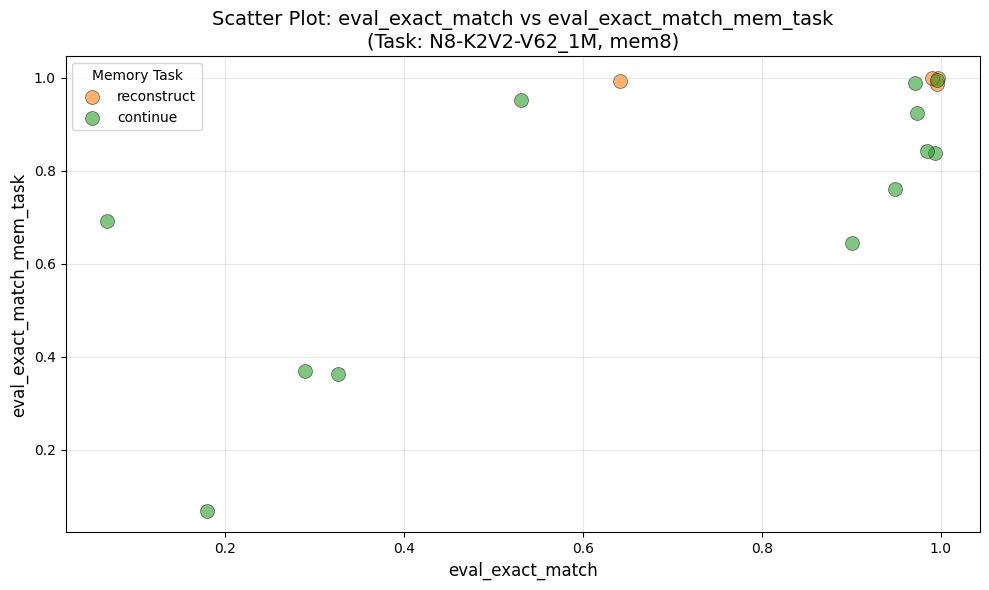

Summary Statistics:
Total data points: 16
  none: 0 points
  reconstruct: 4 points
  continue: 12 points


In [44]:

# Create scatter plot
plt.figure(figsize=(10, 6))

# Define colors for each memory task type
colors = {
    'none': '#1f77b4',        # blue
    'reconstruct': '#ff7f0e',  # orange
    'continue': '#2ca02c'      # green
}

# Plot each memory task type separately
for task_type in ['-', 'reconstruct', 'continue']:
    mask = plot_data['memory_task'] == task_type
    if mask.any():
        plt.scatter(
            plot_data[mask]['eval_exact_match_val'],
            plot_data[mask]['eval_exact_match_mem_task_val'],
            c=colors[task_type],
            label=task_type,
            alpha=0.6,
            s=100,
            edgecolors='black',
            linewidth=0.5
        )

plt.xlabel('eval_exact_match', fontsize=12)
plt.ylabel('eval_exact_match_mem_task', fontsize=12)
plt.title('Scatter Plot: eval_exact_match vs eval_exact_match_mem_task\n(Task: N8-K2V2-V62_1M, mem8)', fontsize=14)
plt.legend(title='Memory Task', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print summary statistics
print("Summary Statistics:")
print(f"Total data points: {len(plot_data)}")
for task_type in ['none', 'reconstruct', 'continue']:
    count = (plot_data['memory_task'] == task_type).sum()
    print(f"  {task_type}: {count} points")

